# Hospital Readmission EDA Project

## Project Overview

This project analyzes hospital readmission data to better understand patterns in excess readmission ratios. The main analytical question is:

**What factors appear to be associated with higher hospital readmission ratios?**

This notebook includes a complete EDA pipeline with data loading, data cleaning, missing value checks, outlier detection using Z-score and IQR, visualizations, findings, and hypotheses for future analysis.

Dataset Source: [PASTE YOUR DATASET URL HERE]

The dataset was successfully downloaded/accessed and loaded into this notebook.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore
from pathlib import Path

SEED = 0
rng = np.random.default_rng(SEED)

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)

DATA_DIR = Path("../data/hospital")
CSV_PATH = DATA_DIR / "FY_2026_Hospital_Readmissions_Reduction_Program_Hospital.csv"

In [2]:
df = pd.read_csv(CSV_PATH)
df.head()

,Facility Name,Facility ID,State,Measure Name,Number of Discharges,Footnote,Excess Readmission Ratio,Predicted Readmission Rate,Expected Readmission Rate,Number of Readmissions,Start Date,End Date
0,SOUTHEAST HEALTH MEDICAL CENTER,10001,AL,READM-30-HIP-KNEE-HRRP,NaN,NaN,0.9875,4.5734,4.6311,Too Few to Report,07/01/2021,06/30/2024
1,SOUTHEAST HEALTH MEDICAL CENTER,10001,AL,READM-30-CABG-HRRP,137.0,NaN,0.9531,10.3960,10.9078,13,07/01/2021,06/30/2024
2,SOUTHEAST HEALTH MEDICAL CENTER,10001,AL,READM-30-AMI-HRRP,273.0,NaN,0.9370,13.2998,14.1948,33,07/01/2021,06/30/2024
3,SOUTHEAST HEALTH MEDICAL CENTER,10001,AL,READM-30-COPD-HRRP,122.0,NaN,0.9823,16.6384,16.9389,19,07/01/2021,06/30/2024
4,SOUTHEAST HEALTH MEDICAL CENTER,10001,AL,READM-30-PN-HRRP,507.0,NaN,0.9871,15.7529,15.9591,79,07/01/2021,06/30/2024


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18330 entries, 0 to 18329
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Facility Name               18330 non-null  object 
 1   Facility ID                 18330 non-null  int64  
 2   State                       18330 non-null  object 
 3   Measure Name                18330 non-null  object 
 4   Number of Discharges        8242 non-null   float64
 5   Footnote                    6987 non-null   float64
 6   Excess Readmission Ratio    11720 non-null  float64
 7   Predicted Readmission Rate  11720 non-null  float64
 8   Expected Readmission Rate   11720 non-null  float64
 9   Number of Readmissions      11720 non-null  object 
 10  Start Date                  18330 non-null  object 
 11  End Date                    18330 non-null  object 
dtypes: float64(5), int64(1), object(6)
memory usage: 1.7+ MB


In [4]:
df.describe()

,Facility ID,Number of Discharges,Footnote,Excess Readmission Ratio,Predicted Readmission Rate,Expected Readmission Rate
count,18330.000000,8242.000000,6987.000000,11720.000000,11720.000000,11720.000000
mean,262031.979378,283.416282,4.550308,1.001777,14.981461,14.947978
std,164868.122655,270.929023,6.181702,0.082050,4.763655,4.620865
min,10001.000000,0.000000,1.000000,0.469800,1.908000,3.087600
25%,110069.000000,117.000000,1.000000,0.958200,12.529550,12.623750
50%,250048.000000,198.000000,5.000000,0.997300,15.860150,15.856550
75%,390138.000000,358.000000,5.000000,1.042300,18.418500,18.500925
max,670342.000000,3672.000000,29.000000,1.629700,28.164300,26.865400


## Basic EDA Clean Up

In [5]:
df.isnull().sum()

Facility Name                     0
Facility ID                       0
State                             0
Measure Name                      0
Number of Discharges          10088
Footnote                      11343
Excess Readmission Ratio       6610
Predicted Readmission Rate     6610
Expected Readmission Rate      6610
Number of Readmissions         6610
Start Date                        0
End Date                          0
dtype: int64

In [6]:
df = df.dropna()

df.isnull().sum()

Facility Name                 0
Facility ID                   0
State                         0
Measure Name                  0
Number of Discharges          0
Footnote                      0
Excess Readmission Ratio      0
Predicted Readmission Rate    0
Expected Readmission Rate     0
Number of Readmissions        0
Start Date                    0
End Date                      0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df = df.drop_duplicates()

In [9]:
df["Number of Discharges"] = pd.to_numeric(df["Number of Discharges"], errors="coerce")
df["Excess Readmission Ratio"] = pd.to_numeric(df["Excess Readmission Ratio"], errors="coerce")
df["Predicted Readmission Rate"] = pd.to_numeric(df["Predicted Readmission Rate"], errors="coerce")
df["Expected Readmission Rate"] = pd.to_numeric(df["Expected Readmission Rate"], errors="coerce")

In [10]:
df = df.dropna()

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 239 entries, 30 to 17987
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Facility Name               239 non-null    object 
 1   Facility ID                 239 non-null    int64  
 2   State                       239 non-null    object 
 3   Measure Name                239 non-null    object 
 4   Number of Discharges        239 non-null    float64
 5   Footnote                    239 non-null    float64
 6   Excess Readmission Ratio    239 non-null    float64
 7   Predicted Readmission Rate  239 non-null    float64
 8   Expected Readmission Rate   239 non-null    float64
 9   Number of Readmissions      239 non-null    object 
 10  Start Date                  239 non-null    object 
 11  End Date                    239 non-null    object 
dtypes: float64(5), int64(1), object(6)
memory usage: 24.3+ KB


## Feature Engineering

Feature engineering involves creating new variables (features) from the existing data to make analysis more meaningful.

These new features can help reveal patterns that are not immediately obvious in the original dataset.

In [11]:
df["Readmission Difference"] = df["Predicted Readmission Rate"] - df["Expected Readmission Rate"]

df[["Predicted Readmission Rate", "Expected Readmission Rate", "Readmission Difference"]].head()

,Predicted Readmission Rate,Expected Readmission Rate,Readmission Difference
30,11.4644,11.8232,-0.3588
31,12.5649,11.2054,1.3595
32,19.9060,19.1894,0.7166
34,19.4501,19.4725,-0.0224
35,16.1282,15.9654,0.1628


This feature shows how much higher or lower the predicted readmission rate is compared to the expected rate.

In [12]:
df["High Readmission"] = df["Excess Readmission Ratio"] > 1

df["High Readmission"].value_counts()

High Readmission
True     132
False    107
Name: count, dtype: int64

In [13]:
df["Discharge Category"] = pd.cut(
    df["Number of Discharges"],
    bins=[0, 100, 300, 1000, df["Number of Discharges"].max()],
    labels=["Low", "Medium", "High", "Very High"]
)

df["Discharge Category"].value_counts()

Discharge Category
Medium       128
High          70
Low           40
Very High      1
Name: count, dtype: int64

## Outlier Detection

Outliers are values that are much higher or lower than most of the data. This project uses two common methods: Z-score and IQR.

In [14]:
z_scores = zscore(df["Excess Readmission Ratio"])

df_z = df[abs(z_scores) < 3]

print("Original dataset size:", df.shape)
print("After Z-score outlier removal:", df_z.shape)
print("Number of rows removed:", len(df) - len(df_z))

Original dataset size: (239, 15)
After Z-score outlier removal: (236, 15)
Number of rows removed: 3


The Z-score method removes values that are more than 3 standard deviations away from the mean. These values are considered extreme outliers.

In [15]:
Q1 = df["Excess Readmission Ratio"].quantile(0.25)
Q3 = df["Excess Readmission Ratio"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_iqr = df[
    (df["Excess Readmission Ratio"] >= lower_bound) &
    (df["Excess Readmission Ratio"] <= upper_bound)
]

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)

print("Original dataset size:", df.shape)
print("After IQR outlier removal:", df_iqr.shape)
print("Number of rows removed:", len(df) - len(df_iqr))

Q1: 0.9598
Q3: 1.0488
IQR: 0.08899999999999997
Lower bound: 0.8263
Upper bound: 1.1823
Original dataset size: (239, 15)
After IQR outlier removal: (235, 15)
Number of rows removed: 4


The IQR method removes values that are too far below Q1 or too far above Q3. This method is useful because it is not as sensitive to extreme values as the mean.

In [16]:
clean_df = df_iqr.copy()

clean_df.head()

,Facility Name,Facility ID,State,Measure Name,Number of Discharges,Footnote,Excess Readmission Ratio,Predicted Readmission Rate,Expected Readmission Rate,Number of Readmissions,Start Date,End Date,Readmission Difference,High Readmission,Discharge Category
30,ST. VINCENT'S EAST,10011,AL,READM-30-AMI-HRRP,118.0,29.0,0.9697,11.4644,11.8232,12,07/01/2021,06/30/2024,-0.3588,False,Medium
31,ST. VINCENT'S EAST,10011,AL,READM-30-CABG-HRRP,63.0,29.0,1.1213,12.5649,11.2054,11,07/01/2021,06/30/2024,1.3595,True,Low
32,ST. VINCENT'S EAST,10011,AL,READM-30-HF-HRRP,268.0,29.0,1.0373,19.9060,19.1894,56,07/01/2021,06/30/2024,0.7166,True,Medium
34,ST. VINCENT'S EAST,10011,AL,READM-30-COPD-HRRP,57.0,29.0,0.9988,19.4501,19.4725,11,07/01/2021,06/30/2024,-0.0224,False,Low
35,ST. VINCENT'S EAST,10011,AL,READM-30-PN-HRRP,281.0,29.0,1.0102,16.1282,15.9654,46,07/01/2021,06/30/2024,0.1628,True,Medium


For the rest of the analysis, the IQR-cleaned dataset will be used because it is a strong method for handling skewed data.

## Exploratory Data Analysis

The following visualizations explore readmission ratios, discharge counts, states, measure types, and hospital patterns.

## Graph 1: Top 10 States for readmission

In [17]:
top_10 = clean_df["State"].value_counts().head(10)
top_10

State
IL    34
FL    32
MI    28
IN    20
TX    19
AL    19
WI    14
TN    12
KS    11
CA     8
Name: count, dtype: int64

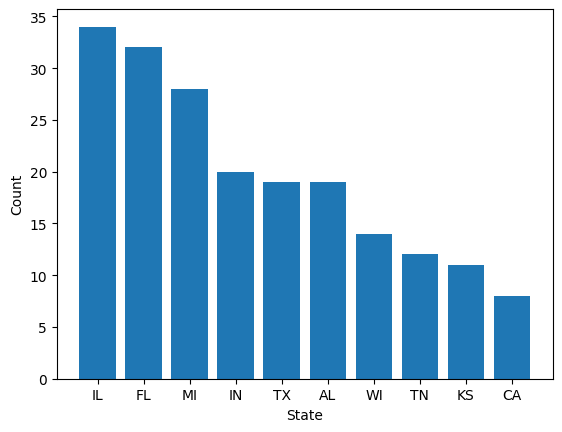

In [18]:
plt.bar(top_10.index, top_10.values)
plt.xlabel("State")
plt.ylabel("Count")
plt.show()

#### Top 10 states for readmission

## Graph 2: Hospital Measure Count

In [19]:
measure_count= clean_df["Measure Name"].value_counts()
measure_count

Measure Name
READM-30-HF-HRRP          70
READM-30-PN-HRRP          69
READM-30-AMI-HRRP         45
READM-30-COPD-HRRP        39
READM-30-CABG-HRRP         8
READM-30-HIP-KNEE-HRRP     4
Name: count, dtype: int64

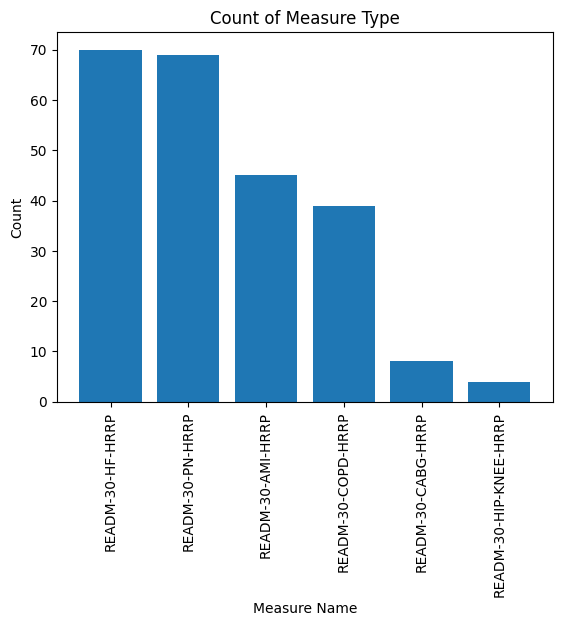

In [20]:
plt.bar(measure_count.index, measure_count.values)
plt.title("Count of Measure Type")
plt.xlabel("Measure Name")
plt.ylabel("Count")
plt.xticks(rotation=90)
plt.show()

#### How many records there are for each hospital readmission measure.

## Graph 3: Excess Readmission Ratio

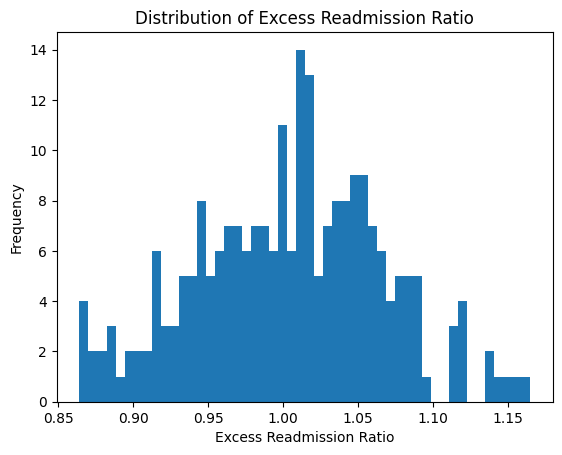

In [21]:
excess_ratio = clean_df["Excess Readmission Ratio"].dropna()
plt.hist(excess_ratio, bins=50)
plt.title("Distribution of Excess Readmission Ratio")
plt.xlabel("Excess Readmission Ratio")
plt.ylabel("Frequency")
plt.show()

#### Most Hospitals are have an excess readmission ratio close to 1

## Graph 4: Top 10 Hospitals with the highest excess ratios

In [22]:
top_10_ratio = clean_df.sort_values(
    by="Excess Readmission Ratio",
    ascending=False
).head(10).copy()

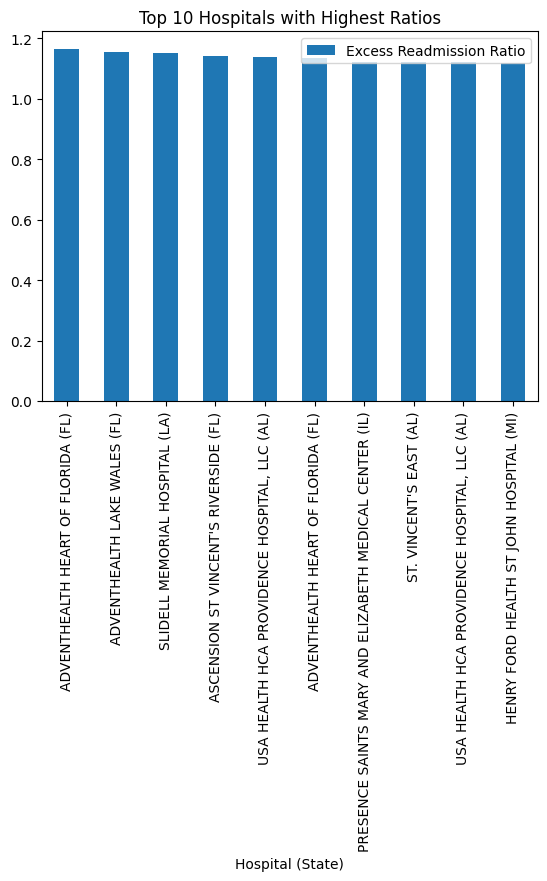

In [23]:
top_10_ratio["Hospital_State"] = top_10_ratio["Facility Name"] + " (" + top_10_ratio["State"] + ")"

top_10_ratio.plot(
    x="Hospital_State",
    y="Excess Readmission Ratio",
    kind="bar"
)

plt.xticks(rotation=90)
plt.title("Top 10 Hospitals with Highest Ratios")
plt.xlabel("Hospital (State)")
plt.show()

#### These are the top 10 hositals with the highest excess ratio

## Graph 5: Expected vs Predicted Rate 

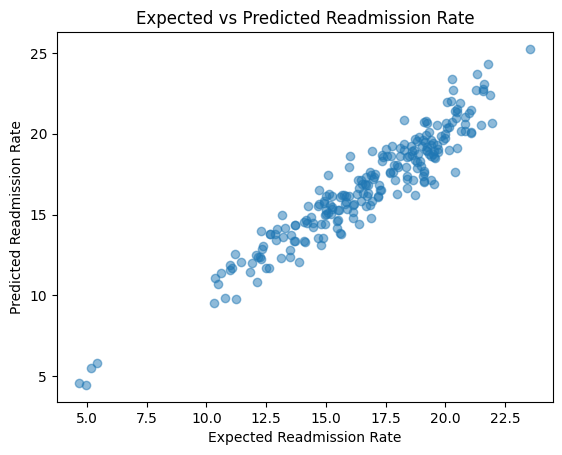

In [24]:
plt.scatter(
    clean_df["Expected Readmission Rate"],
    clean_df["Predicted Readmission Rate"],
    alpha=0.5
)
plt.title("Expected vs Predicted Readmission Rate")
plt.xlabel("Expected Readmission Rate")
plt.ylabel("Predicted Readmission Rate")
plt.show()

#### The correlation of expected to predicted readmission rates 

## Graph 6: Number of Discharges By Measure

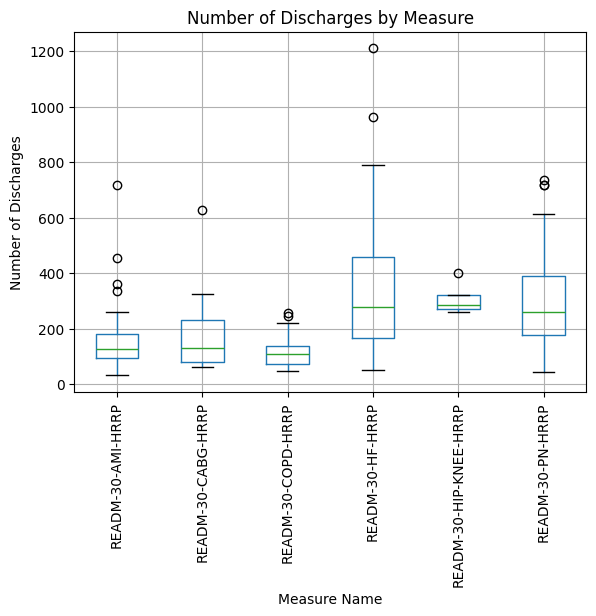

In [25]:
clean_df.boxplot(column="Number of Discharges", by="Measure Name", rot=90)
plt.title("Number of Discharges by Measure")
plt.suptitle("")
plt.xlabel("Measure Name")
plt.ylabel("Number of Discharges")
plt.show()

#### Comparing discharge counts across the different measure categories

/var/folders/5w/lxp65hpj0djbcw8vktxcgd9w0000gn/T/ipykernel_41276/3167228686.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  clean_df.groupby("Discharge Category")["Excess Readmission Ratio"].mean().plot(kind="bar")


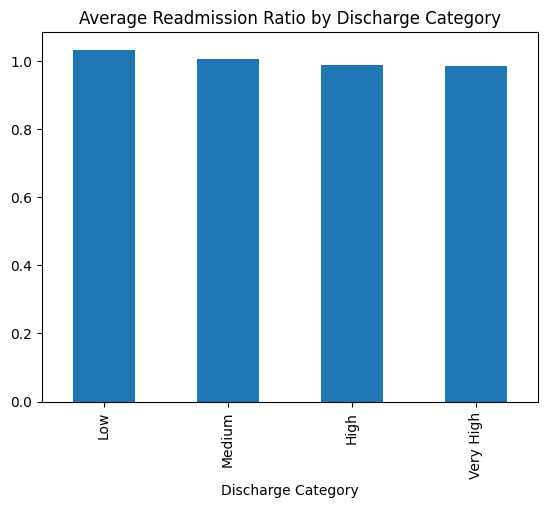

In [26]:
clean_df.groupby("Discharge Category")["Excess Readmission Ratio"].mean().plot(kind="bar")
plt.title("Average Readmission Ratio by Discharge Category")
plt.show()

## Initial Findings

- The dataset contains hospital readmission information from different hospitols accross many states
- Many southern states have a higher readmission count with Texas and Florida being the top two
- The predicted and expected readmission rates have a strong coorelation
- Heart Failure and pneumonia appear to be the measures with the highest discharge rate
- The hospital with the highest excess ratio is not from the 6th highest state 

## Hypotheses for Further Exploration

1. Hospitals with higher expected readmission rates may also have higher predicted readmission rates
2. Some measure types may have higher excess readmission ratios than others
3. These high readmission hospitals may be in lower income areas
4. These hospitals may also be in highly populated areas
5. Excess readmission ratio and readmission rate may have a weaker connection than expected